## 1. Importação das bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas para carregamento, organização e visualização dos dados.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Carregamento do dataset

O conjunto de dados contém informações cadastrais e profissionais de 20 funcionários.

In [5]:
from pathlib import Path

caminhos = [
    Path("../data/funcionarios.csv"),
    Path("data/funcionarios.csv"),
    Path("funcionarios.csv")
]

caminho = next((p for p in caminhos if p.exists()), None)
if caminho is None:
    raise FileNotFoundError("Arquivo funcionarios_simulado.csv não encontrado.")

df = pd.read_csv(caminho)
df.head()

,ID,Nome,Idade,Departamento,Cargo,Experiência (anos),Horas Semanais,Remoto,Desempenho,Salário,Satisfação,Horas Trabalhadas
0,1,Ana,27,Vendas,Assistente,2.0,40,Sim,7.5,2800,7.5,40
1,2,Bruno,35,TI,Analista,6.0,42,Não,6.8,6200,7.3,41
2,3,Carla,30,RH,Coordenador,5.0,38,Sim,8.1,6800,8.3,38
3,4,Diego,41,TI,Engenheiro,12.0,45,Não,7.0,9800,7.9,46
4,5,Elisa,24,Vendas,Estagiária,0.5,30,Sim,9.0,1500,8.4,30


## 3. Validação inicial dos dados

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  20 non-null     int64  
 1   Nome                20 non-null     str    
 2   Idade               20 non-null     int64  
 3   Departamento        20 non-null     str    
 4   Cargo               20 non-null     str    
 5   Experiência (anos)  20 non-null     float64
 6   Horas Semanais      20 non-null     int64  
 7   Remoto              20 non-null     str    
 8   Desempenho          20 non-null     float64
 9   Salário             20 non-null     int64  
 10  Satisfação          20 non-null     float64
 11  Horas Trabalhadas   20 non-null     int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 2.5 KB


In [7]:
print("Valores ausentes por coluna:")
display(df.isnull().sum())

print("Quantidade de registros duplicados:")
print(df.duplicated().sum())

Valores ausentes por coluna:


ID                    0
Nome                  0
Idade                 0
Departamento          0
Cargo                 0
Experiência (anos)    0
Horas Semanais        0
Remoto                0
Desempenho            0
Salário               0
Satisfação            0
Horas Trabalhadas     0
dtype: int64

Quantidade de registros duplicados:
0


In [8]:
df.describe()

,ID,Idade,Experiência (anos),Horas Semanais,Desempenho,Salário,Satisfação,Horas Trabalhadas
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000,20.00000
mean,10.50000,33.350000,7.375000,41.100000,7.385000,6975.000000,7.80500,41.25000
std,5.91608,6.335157,5.065038,4.435503,0.987967,3224.229814,0.35015,4.66651
min,1.00000,24.000000,0.500000,30.000000,5.700000,1500.000000,7.20000,30.00000
25%,5.75000,28.750000,3.750000,39.000000,6.725000,5100.000000,7.57500,39.00000
50%,10.50000,32.500000,6.000000,40.500000,7.450000,6900.000000,7.80000,40.50000
75%,15.25000,38.250000,10.250000,44.000000,8.150000,8275.000000,8.02500,44.25000
max,20.00000,46.000000,20.000000,50.000000,9.000000,14500.000000,8.40000,50.00000


Não foram identificados valores ausentes ou registros duplicados. As variáveis apresentam tipos compatíveis com suas respectivas características e os valores observados encontram-se em faixas coerentes para a análise proposta. Dessa forma, não foi necessário realizar procedimentos adicionais de limpeza ou transformação dos dados.

## 4. Descrição das variáveis

O conjunto de dados contém informações cadastrais e profissionais dos funcionários.

As principais variáveis utilizadas na análise são:

- `Idade`: idade do funcionário;
- `Departamento`: setor em que o funcionário trabalha;
- `Cargo`: função exercida;
- `Experiência (anos)`: tempo de experiência profissional;
- `Horas Semanais`: quantidade de horas semanais previstas;
- `Remoto`: indica se o funcionário trabalha remotamente;
- `Desempenho`: indicador numérico de desempenho;
- `Salário`: valor salarial simulado;
- `Satisfação`: nível de satisfação simulado;
- `Horas Trabalhadas`: quantidade de horas trabalhadas.

As variáveis `Salário`, `Satisfação` e `Horas Trabalhadas` foram adicionadas por simulação, pois são solicitadas no roteiro da atividade, mas não aparecem na tabela original fornecida. As demais variáveis foram mantidas sem alterações.

## 5. Histogramas — Distribuição das Variáveis

Os histogramas são utilizados para observar como os valores das variáveis numéricas estão distribuídos no conjunto de dados.

### Idade

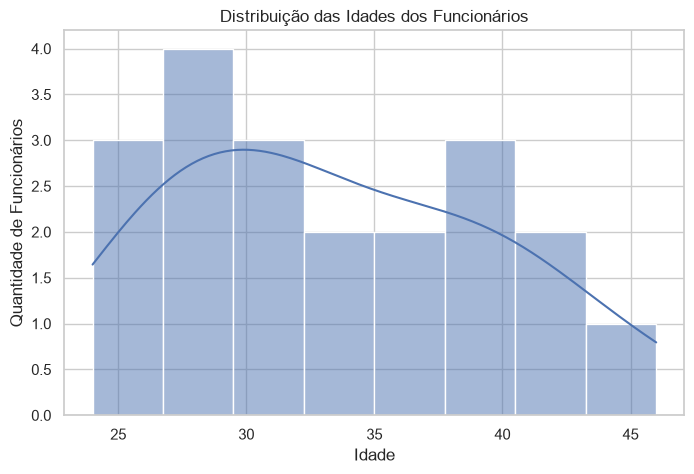

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Idade", bins=8, kde=True)
plt.title("Distribuição das Idades dos Funcionários")
plt.xlabel("Idade")
plt.ylabel("Quantidade de Funcionários")
plt.show()

### Interpretação

A distribuição das idades apresenta maior concentração entre aproximadamente 24 e 32 anos. Também existem funcionários em faixas etárias mais elevadas, chegando a 46 anos, indicando uma composição etária diversificada.

### Salário

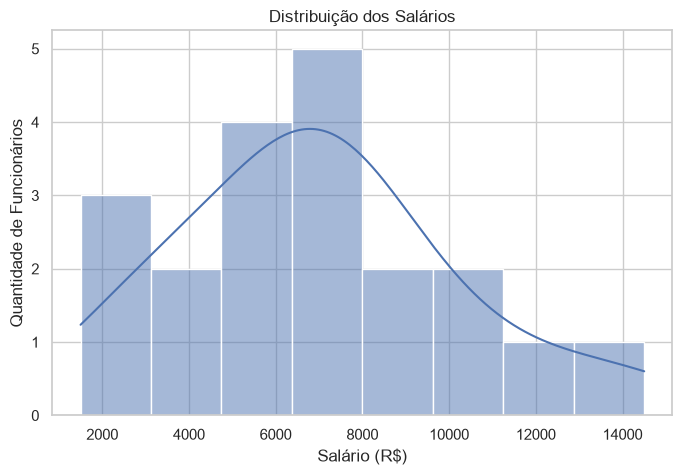

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Salário", bins=8, kde=True)
plt.title("Distribuição dos Salários")
plt.xlabel("Salário (R$)")
plt.ylabel("Quantidade de Funcionários")
plt.show()

### Interpretação

Os salários apresentam maior concentração nas faixas intermediárias, especialmente entre aproximadamente R$ 4.000 e R$ 8.000. Também aparecem salários inferiores a R$ 4.000 e alguns valores superiores a R$ 10.000, associados a funções de maior responsabilidade.

### Satisfação

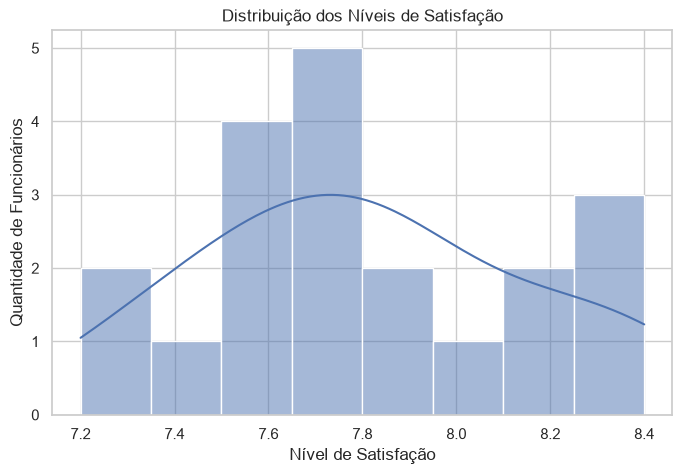

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Satisfação", bins=8, kde=True)
plt.title("Distribuição dos Níveis de Satisfação")
plt.xlabel("Nível de Satisfação")
plt.ylabel("Quantidade de Funcionários")
plt.show()

### Interpretação

Os níveis de satisfação estão concentrados principalmente entre aproximadamente 7,2 e 8,4. Há variação entre os funcionários, mas os valores permanecem predominantemente nas faixas intermediárias e altas.

### Horas Trabalhadas

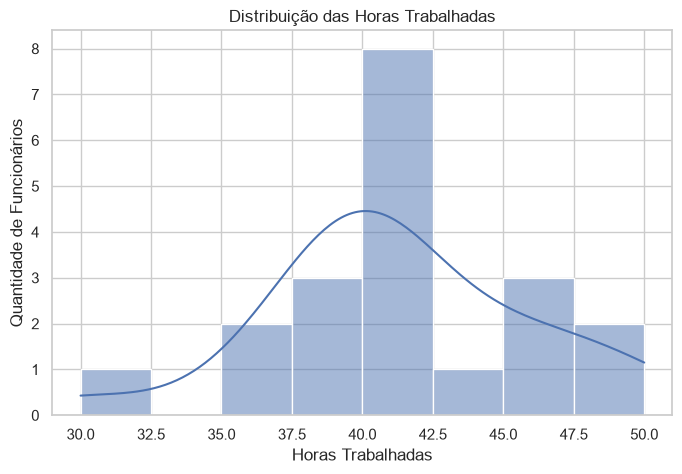

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Horas Trabalhadas", bins=8, kde=True)
plt.title("Distribuição das Horas Trabalhadas")
plt.xlabel("Horas Trabalhadas")
plt.ylabel("Quantidade de Funcionários")
plt.show()

### Interpretação

A maior parte dos funcionários apresenta quantidade de horas trabalhadas próxima da faixa de 39 a 45 horas. Também existem registros abaixo dessa faixa e alguns registros acima, chegando a 50 horas.

## 6. Boxplots por Departamento

Os boxplots são utilizados para comparar a distribuição das variáveis numéricas entre os diferentes departamentos. Essa visualização permite observar a mediana, a dispersão dos valores e possíveis valores discrepantes dentro de cada setor.

### Idade por Departamento

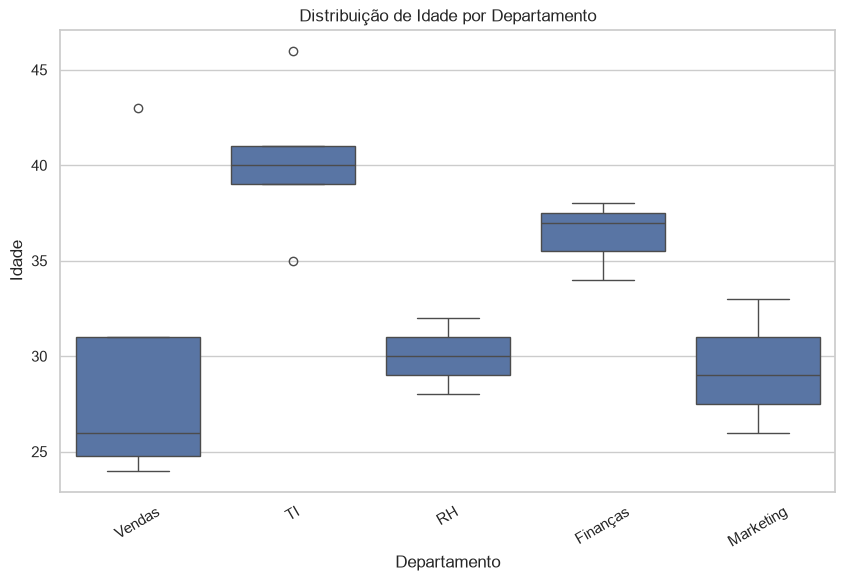

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Departamento", y="Idade")
plt.title("Distribuição de Idade por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Idade")
plt.xticks(rotation=30)
plt.show()

### Experiência (anos) por Departamento

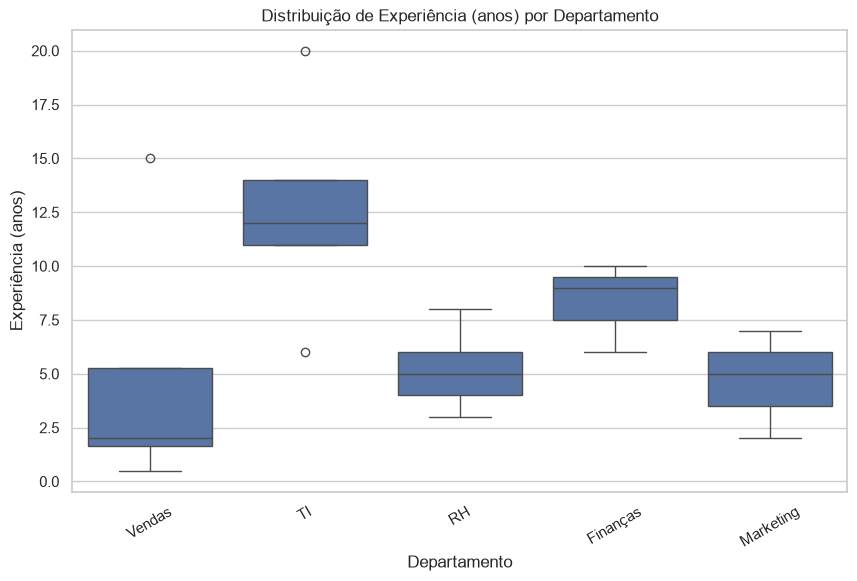

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Departamento", y="Experiência (anos)")
plt.title("Distribuição de Experiência (anos) por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Experiência (anos)")
plt.xticks(rotation=30)
plt.show()

### Horas Semanais por Departamento

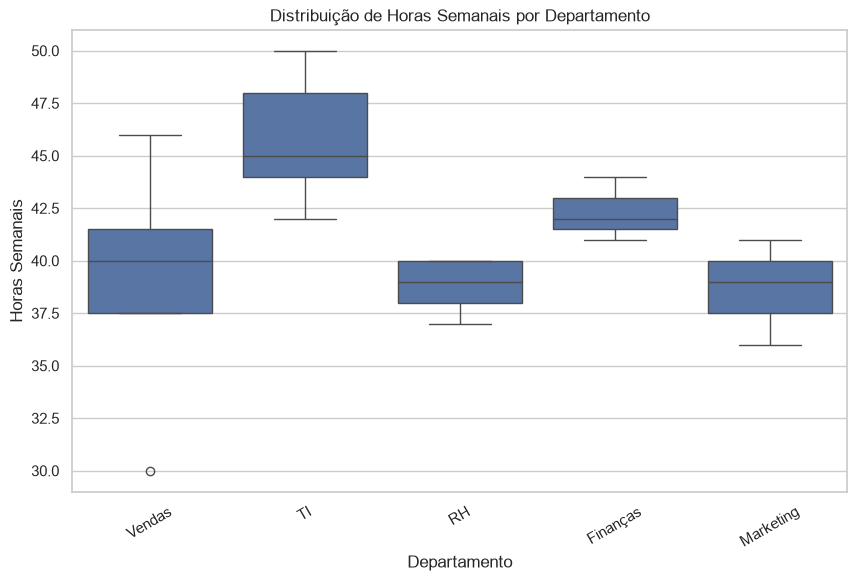

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Departamento", y="Horas Semanais")
plt.title("Distribuição de Horas Semanais por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Horas Semanais")
plt.xticks(rotation=30)
plt.show()

### Desempenho por Departamento

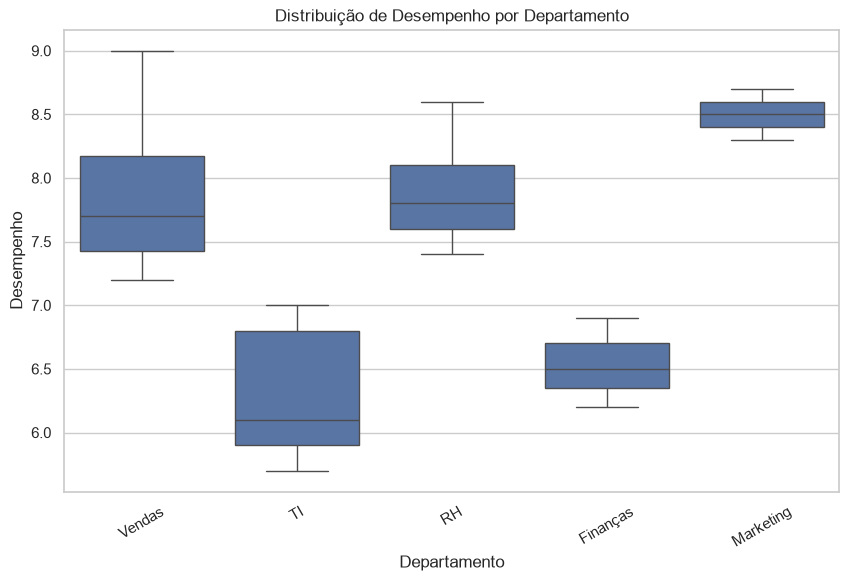

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Departamento", y="Desempenho")
plt.title("Distribuição de Desempenho por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Desempenho")
plt.xticks(rotation=30)
plt.show()

### Salário por Departamento

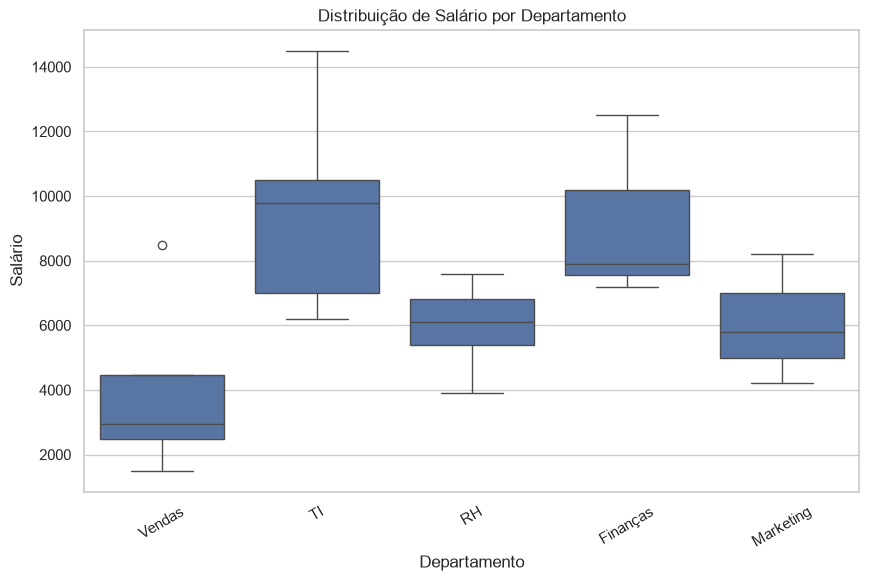

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Departamento", y="Salário")
plt.title("Distribuição de Salário por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Salário")
plt.xticks(rotation=30)
plt.show()

### Satisfação por Departamento

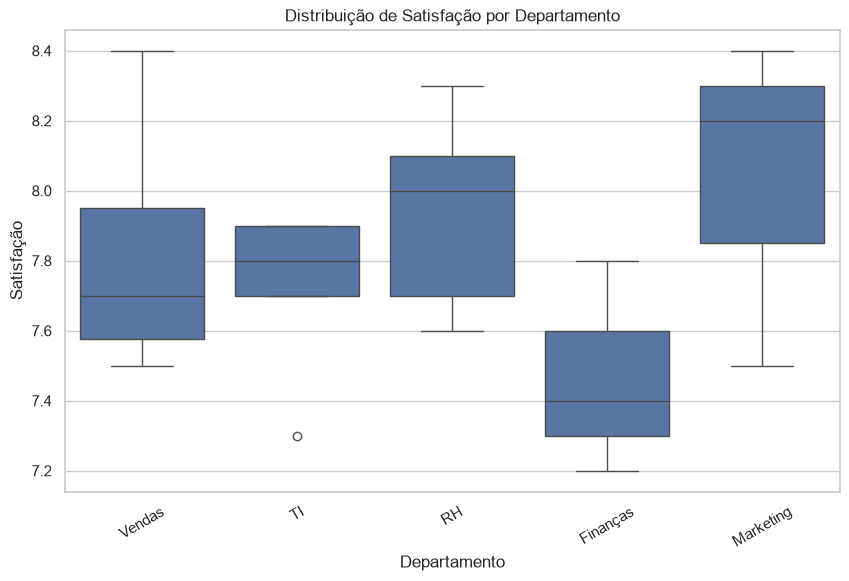

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Departamento", y="Satisfação")
plt.title("Distribuição de Satisfação por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Satisfação")
plt.xticks(rotation=30)
plt.show()

### Horas Trabalhadas por Departamento

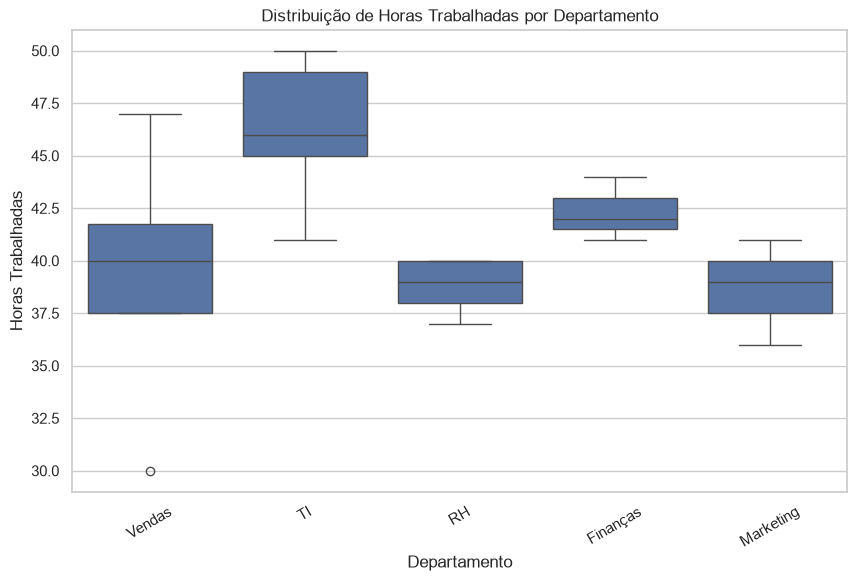

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Departamento", y="Horas Trabalhadas")
plt.title("Distribuição de Horas Trabalhadas por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Horas Trabalhadas")
plt.xticks(rotation=30)
plt.show()

### Identificação de possíveis valores discrepantes

Os possíveis valores discrepantes são identificados pelo critério do intervalo interquartil (IQR), utilizando os limites Q1 − 1,5 × IQR e Q3 + 1,5 × IQR.

In [20]:
def identificar_outliers_por_departamento(dataframe, variavel):
    resultados = []
    for departamento, grupo in dataframe.groupby("Departamento"):
        serie = grupo[variavel].dropna()
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        outliers = serie[(serie < limite_inferior) | (serie > limite_superior)].tolist()
        resultados.append({
            "Departamento": departamento,
            "Variável": variavel,
            "Limite inferior": round(limite_inferior, 2),
            "Limite superior": round(limite_superior, 2),
            "Possíveis outliers": outliers
        })
    return pd.DataFrame(resultados)

for variavel in ["Idade", "Experiência (anos)", "Horas Semanais", "Desempenho", "Salário", "Satisfação", "Horas Trabalhadas"]:
    print(f"\n{variavel}")
    display(identificar_outliers_por_departamento(df, variavel))


Idade


,Departamento,Variável,Limite inferior,Limite superior,Possíveis outliers
0,Finanças,Idade,32.50,40.50,[]
1,Marketing,Idade,22.25,36.25,[]
2,RH,Idade,26.00,34.00,[]
3,TI,Idade,36.00,44.00,"[35, 46]"
4,Vendas,Idade,15.38,40.38,[43]



Experiência (anos)


,Departamento,Variável,Limite inferior,Limite superior,Possíveis outliers
0,Finanças,Experiência (anos),4.50,12.50,[]
1,Marketing,Experiência (anos),-0.25,9.75,[]
2,RH,Experiência (anos),1.00,9.00,[]
3,TI,Experiência (anos),6.50,18.50,"[6.0, 20.0]"
4,Vendas,Experiência (anos),-3.81,10.69,[15.0]



Horas Semanais


...

,Departamento,Variável,Limite inferior,Limite superior,Possíveis outliers
0,Finanças,Salário,3575.0,14175.0,[]
1,Marketing,Salário,2000.0,10000.0,[]
2,RH,Salário,3300.0,8900.0,[]
3,TI,Salário,1750.0,15750.0,[]
4,Vendas,Salário,-487.5,7412.5,[8500]



Satisfação


,Departamento,Variável,Limite inferior,Limite superior,Possíveis outliers
0,Finanças,Satisfação,6.85,8.05,[]
1,Marketing,Satisfação,7.17,8.98,[]
2,RH,Satisfação,7.10,8.70,[]
3,TI,Satisfação,7.40,8.20,[7.3]
4,Vendas,Satisfação,7.01,8.51,[]



Horas Trabalhadas


,Departamento,Variável,Limite inferior,Limite superior,Possíveis outliers
0,Finanças,Horas Trabalhadas,39.25,45.25,[]
1,Marketing,Horas Trabalhadas,33.75,43.75,[]
2,RH,Horas Trabalhadas,35.00,43.00,[]
3,TI,Horas Trabalhadas,39.00,55.00,[]
4,Vendas,Horas Trabalhadas,31.12,48.12,[30]


### Interpretação

Os boxplots permitem comparar as variáveis numéricas entre os departamentos e observar diferenças de mediana, dispersão e possíveis valores discrepantes. As maiores diferenças entre os setores aparecem principalmente nas distribuições de salário e horas trabalhadas. Valores extremos devem ser interpretados considerando o contexto de cada variável, pois um valor discrepante pelo critério estatístico não significa necessariamente erro no dado.

## 7. Gráficos de dispersão

Os gráficos de dispersão são utilizados para investigar possíveis relações entre pares de variáveis numéricas.

### Salário × Satisfação

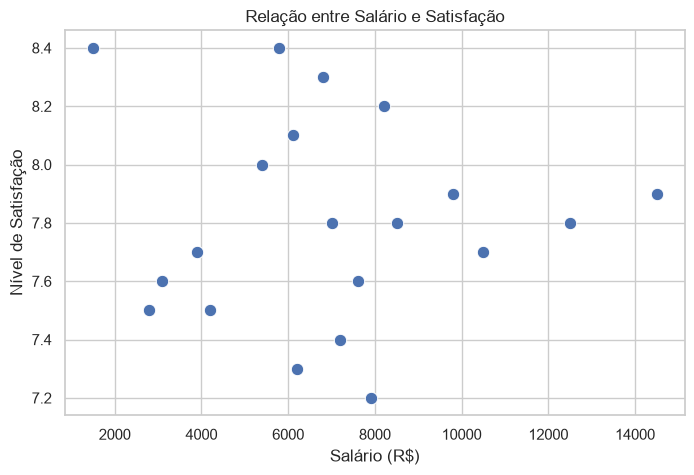

Correlação entre Salário e Satisfação: -0.033


In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Salário", y="Satisfação", s=80)
plt.title("Relação entre Salário e Satisfação")
plt.xlabel("Salário (R$)")
plt.ylabel("Nível de Satisfação")
plt.show()

correlacao_salario_satisfacao = df["Salário"].corr(df["Satisfação"])
print(f"Correlação entre Salário e Satisfação: {correlacao_salario_satisfacao:.3f}")

### Interpretação

O gráfico apresenta os níveis de satisfação distribuídos em diferentes faixas salariais, sem um padrão linear forte. Funcionários com salários mais altos aparecem com diferentes níveis de satisfação, assim como funcionários com salários menores. A correlação calculada no notebook complementa essa interpretação visual.

### Horas Trabalhadas × Salário

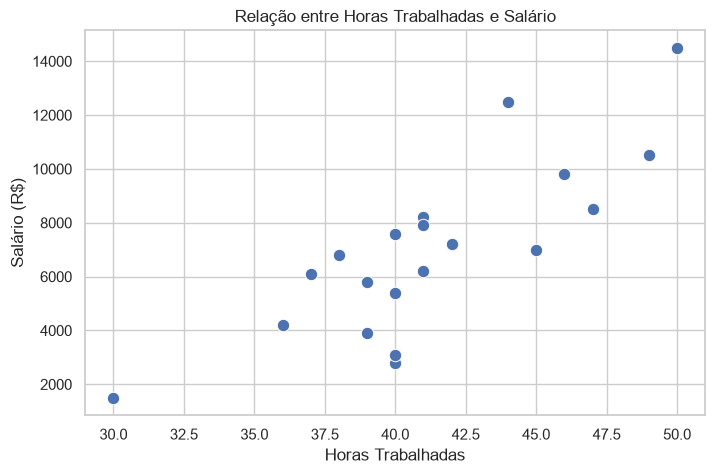

Correlação entre Horas Trabalhadas e Salário: 0.811


In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Horas Trabalhadas", y="Salário", s=80)
plt.title("Relação entre Horas Trabalhadas e Salário")
plt.xlabel("Horas Trabalhadas")
plt.ylabel("Salário (R$)")
plt.show()

correlacao_horas_salario = df["Horas Trabalhadas"].corr(df["Salário"])
print(f"Correlação entre Horas Trabalhadas e Salário: {correlacao_horas_salario:.3f}")

### Interpretação

O gráfico permite observar uma tendência positiva entre horas trabalhadas e salário. Essa associação ocorre em parte porque cargos de maior responsabilidade estão representados por maiores jornadas e salários. A relação observada não significa, isoladamente, que trabalhar mais horas seja a causa de um salário maior.

## 8. Respostas às questões propostas

In [23]:
medianas_salario = df.groupby("Departamento")["Salário"].median().sort_values(ascending=False)
corr_salario_satisfacao = df["Salário"].corr(df["Satisfação"])
corr_horas_satisfacao = df["Horas Trabalhadas"].corr(df["Satisfação"])

print("Mediana salarial por departamento:")
display(medianas_salario)
print(f"Correlação Salário × Satisfação: {corr_salario_satisfacao:.3f}")
print(f"Correlação Horas Trabalhadas × Satisfação: {corr_horas_satisfacao:.3f}")

Mediana salarial por departamento:


Departamento
TI           9800.0
Finanças     7900.0
RH           6100.0
Marketing    5800.0
Vendas       2950.0
Name: Salário, dtype: float64

Correlação Salário × Satisfação: -0.033
Correlação Horas Trabalhadas × Satisfação: -0.262


### 1) Como é a distribuição das idades dos funcionários?

As idades variam de 24 a 46 anos, com maior concentração nas faixas mais jovens, especialmente entre aproximadamente 24 e 32 anos. Ainda assim, há funcionários em diferentes faixas etárias.

### 2) Há setores com maior concentração de salários altos?

Sim. A comparação dos boxplots e das medianas salariais indica maior concentração de salários elevados em TI e Finanças. TI apresenta a maior mediana salarial do conjunto analisado.

### 3) Existe uma relação perceptível entre o salário e o nível de satisfação?

Não há um padrão linear forte entre salário e satisfação. A correlação calculada no notebook é utilizada para complementar essa observação visual.

### 4) Funcionários que trabalham mais horas apresentam maior insatisfação?

Os dados não permitem afirmar que trabalhar mais horas implique maior insatisfação. A correlação entre horas trabalhadas e satisfação é calculada no notebook e deve ser interpretada junto ao gráfico de dispersão.

## 9. Conclusão

As visualizações permitiram analisar a distribuição das principais variáveis e comparar seu comportamento entre os departamentos. Os histogramas mostraram a distribuição das idades, salários, níveis de satisfação e horas trabalhadas. Os boxplots permitiram comparar as variáveis numéricas entre os setores e identificar possíveis valores discrepantes. Os gráficos de dispersão permitiram investigar as relações entre salário e satisfação e entre horas trabalhadas e salário.

De modo geral, a análise evidencia diferenças entre os departamentos, principalmente nas distribuições salariais e nas cargas de trabalho, enquanto as relações entre as variáveis devem ser interpretadas considerando a dispersão dos dados e o contexto dos funcionários analisados.